# 04 · TabPFN-3.5 vs six classic learners and the market itself (CPU only)

The protocol is fixed in [`PREREG.md`](../PREREG.md), which was written before any test fold was run.
- Weekly walk-forward test blocks.
- Every model trains only on markets that closed before the block starts.
- **Policy A:** every model sees the same 5,000 most recent rows.
- Classic learners are tuned on a validation slice (defaults + 20 random configurations). TabPFN is not tuned.

`make benchmark` reruns everything (a few hours on an 8-core CPU). This notebook reads the cached
results in `results/`.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tabtrader import plots
plots.style()
pd.set_option("display.width", 140, "display.max_columns", 30)

In [2]:
S = json.loads((ROOT / "results" / "summary.json").read_text())
def board(market, policy="policy_A"):
    L = S[market][policy]
    rows = []
    for m, r in L["models"].items():
        v, mk = r.get("vs_ref"), r.get("vs_market")
        rows.append({"model": m, "log loss": r["logloss"], "Brier": r["brier"], "AUC": r["auc"], "ECE": r["ece"],
                     "Δ vs TabPFN-3.5": None if not v else v["mean"],
                     "95% CI": None if not v else f"[{v['lo']:+.4f}, {v['hi']:+.4f}]",
                     "BH": None if not v else v.get("bh_pass"),
                     "Δ vs market": None if not mk else mk["mean"],
                     "fit s": r["cpu"].get("fit_s_mean"), "tune s": r["cpu"].get("search_s_mean"),
                     "1 market s": r["cpu"].get("single_market_s")})
    return pd.DataFrame(rows).sort_values("log loss").set_index("model")
print(S["15m"]["policy_A"]["n_rows"], "test rows over", S["15m"]["policy_A"]["n_days"], "days (15-minute)")
board("15m").round(4)

9686 test rows over 62 days (15-minute)


,log loss,Brier,AUC,ECE,Δ vs TabPFN-3.5,95% CI,BH,Δ vs market,fit s,tune s,1 market s
model,,,,,,,,,,,
Market price,0.4745,0.1571,0.8521,0.0155,-0.0024,"[-0.0044, -0.0003]",True,NaN,0.00,0.00,0.000
Logistic regression · tuned,0.4763,0.1576,0.8509,0.0092,-0.0005,"[-0.0021, +0.0010]",False,0.0018,0.04,0.78,0.001
TabPFN-3.5,0.4768,0.1577,0.8508,0.0107,NaN,None,None,0.0024,145.87,0.00,1.701
TabPFN-3.5-Fast,0.4771,0.1577,0.8506,0.0103,0.0002,"[-0.0003, +0.0008]",False,0.0026,35.53,0.00,0.356
Random forest · tuned,0.4815,0.1589,0.8485,0.0131,0.0046,"[+0.0021, +0.0071]",True,0.0070,0.52,3.87,0.041
CatBoost · tuned,0.4816,0.1591,0.8482,0.0136,0.0048,"[+0.0023, +0.0070]",True,0.0071,0.92,44.00,0.001
XGBoost · tuned,0.4819,0.1590,0.8481,0.0134,0.0050,"[+0.0023, +0.0077]",True,0.0074,3.61,129.13,0.010
MLP · tuned,0.4834,0.1602,0.8463,0.0186,0.0066,"[+0.0038, +0.0093]",True,0.0089,0.46,10.48,0.001
LightGBM · tuned,0.4845,0.1598,0.8465,0.0143,0.0077,"[+0.0050, +0.0105]",True,0.0100,1.83,127.25,0.001


In [3]:
print(S["1h"]["policy_A"]["n_rows"], "test rows over", S["1h"]["policy_A"]["n_days"], "days (hourly)")
board("1h").round(4)

4790 test rows over 41 days (hourly)


,log loss,Brier,AUC,ECE,Δ vs TabPFN-3.5,95% CI,BH,Δ vs market,fit s,tune s,1 market s
model,,,,,,,,,,,
Market price,0.5395,0.1802,0.8053,0.0182,-0.0047,"[-0.0102, +0.0004]",False,NaN,0.00,0.00,0.000
TabPFN-3.5,0.5442,0.1818,0.8030,0.0316,NaN,None,None,0.0047,101.79,0.00,0.326
Logistic regression · tuned,0.5452,0.1825,0.8019,0.0296,0.0010,"[-0.0030, +0.0049]",False,0.0056,0.03,0.71,0.001
Random forest · tuned,0.5456,0.1820,0.8028,0.0367,0.0014,"[-0.0012, +0.0040]",False,0.0060,0.47,3.17,0.041
LightGBM · tuned,0.5458,0.1821,0.8038,0.0379,0.0017,"[-0.0017, +0.0050]",False,0.0063,0.05,8.85,0.001
MLP · tuned,0.5464,0.1826,0.8013,0.0312,0.0022,"[-0.0035, +0.0080]",False,0.0069,0.17,7.77,0.001
CatBoost · tuned,0.5486,0.1834,0.7981,0.0251,0.0044,"[+0.0002, +0.0088]",False,0.0090,1.00,34.04,0.001
XGBoost · tuned,0.5512,0.1843,0.7960,0.0260,0.0070,"[+0.0021, +0.0126]",True,0.0116,0.17,8.43,0.000
TabPFN-3.5-Fast,0.5522,0.1848,0.7959,0.0303,0.0080,"[+0.0031, +0.0136]",True,0.0127,25.88,0.00,0.096


### Paired difference in log loss vs TabPFN-3.5 (right of zero = the model is worse than TabPFN)

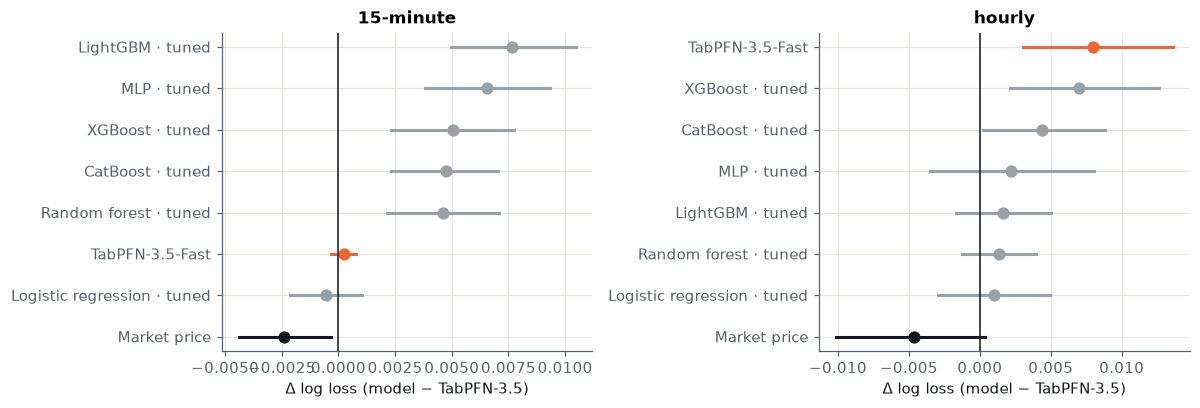

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for ax, mk in zip(axes, ["15m", "1h"]):
    L = S[mk]["policy_A"]["models"]
    items = sorted([(m, r["vs_ref"]) for m, r in L.items() if r.get("vs_ref")], key=lambda x: x[1]["mean"])
    for i, (m, v) in enumerate(items):
        ax.plot([v["lo"], v["hi"]], [i, i], color=plots.color(m), lw=2)
        ax.plot(v["mean"], i, "o", color=plots.color(m), ms=7)
    ax.set_yticks(range(len(items)), [m for m, _ in items]); ax.axvline(0, color=plots.INK, lw=1)
    ax.set_title({"15m": "15-minute", "1h": "hourly"}[mk]); ax.set_xlabel("Δ log loss (model − TabPFN-3.5)")
plt.tight_layout()

### Learning curves: log loss vs the number of training rows (library defaults)

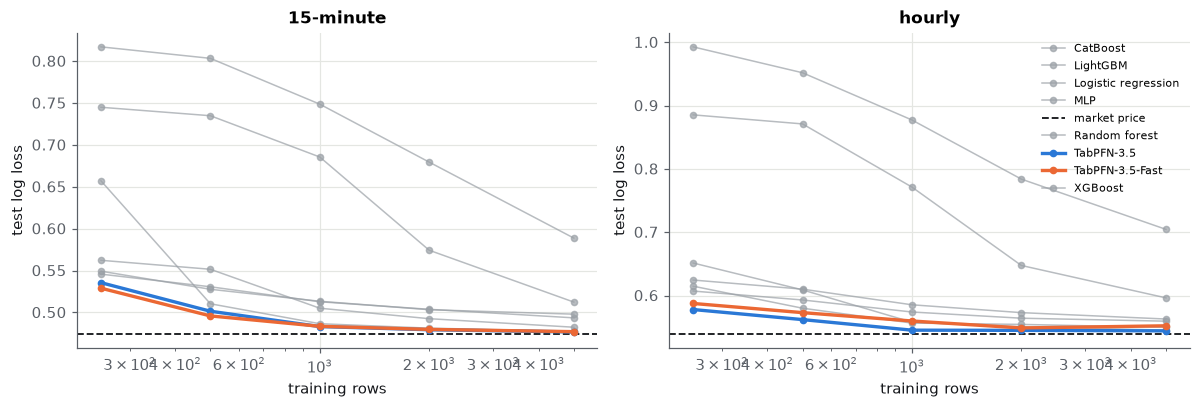

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, mk in zip(axes, ["15m", "1h"]):
    lc = S[mk]["learning_curve"]
    ns = [int(n) for n in lc]
    models = sorted({m for n in lc for m in lc[n]})
    for m in models:
        ys = [lc[n].get(m, {}).get("logloss") for n in lc]
        if m == "Market price":
            ax.axhline(ys[-1], color=plots.INK, ls="--", lw=1.2, label="market price")
            continue
        hi = m.startswith("TabPFN")
        ax.plot(ns, ys, marker="o", ms=4, color=plots.color(m), lw=2.2 if hi else 1, alpha=1 if hi else .7,
                label=m.replace(" · default", ""))
    ax.set_xscale("log"); ax.set_xlabel("training rows"); ax.set_ylabel("test log loss")
    ax.set_title({"15m": "15-minute", "1h": "hourly"}[mk])
axes[1].legend(fontsize=7.5, loc="upper right"); plt.tight_layout()

### Calibration (reliability) on the test blocks

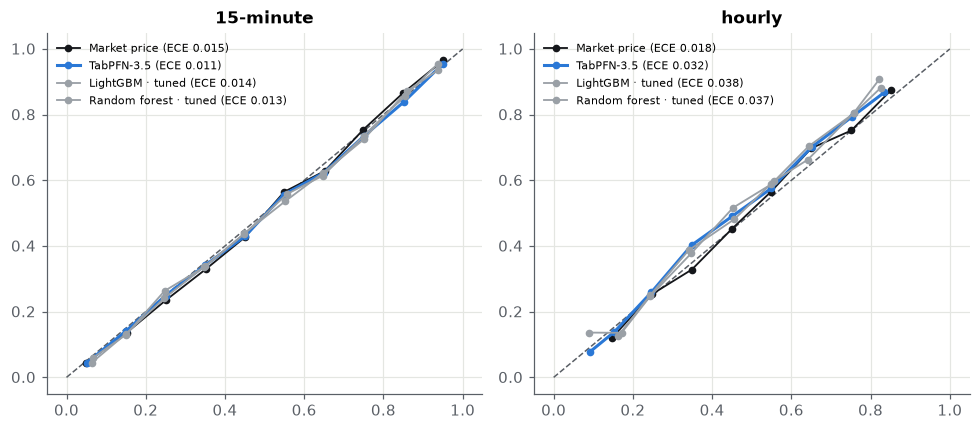

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, mk in zip(axes, ["15m", "1h"]):
    ax.plot([0, 1], [0, 1], color=plots.MUTED, ls="--", lw=1)
    for m in ["Market price", "TabPFN-3.5", "LightGBM · tuned", "Random forest · tuned"]:
        r = S[mk]["policy_A"]["models"].get(m)
        if not r: continue
        rel = pd.DataFrame(r["reliability"])
        ax.plot(rel.p_mean, rel.y_mean, marker="o", ms=4, color=plots.color(m),
                lw=2 if m.startswith("TabPFN") else 1.2, label=f"{m} (ECE {r['ece']:.3f})")
    ax.set_title({"15m": "15-minute", "1h": "hourly"}[mk]); ax.legend(fontsize=7.5)
plt.tight_layout()

### Policy B: the classic learners get *all* history; TabPFN stays at 5,000 rows

In [7]:
for mk in ["15m", "1h"]:
    if S[mk].get("policy_B"):
        print(mk); display(board(mk, "policy_B")[["log loss", "AUC", "Δ vs TabPFN-3.5", "95% CI", "BH"]].round(4))

15m


,log loss,AUC,Δ vs TabPFN-3.5,95% CI,BH
model,,,,,
Market price,0.4745,0.8521,-0.0024,"[-0.0044, -0.0003]",True
Logistic regression · tuned,0.4759,0.8514,-0.0010,"[-0.0030, +0.0011]",False
TabPFN-3.5,0.4768,0.8508,NaN,None,None
MLP · tuned,0.4800,0.8488,0.0032,"[+0.0002, +0.0066]",True
CatBoost · tuned,0.4807,0.8494,0.0038,"[+0.0012, +0.0063]",True
Random forest · tuned,0.4814,0.8489,0.0045,"[+0.0020, +0.0070]",True
LightGBM · tuned,0.4822,0.8481,0.0053,"[+0.0023, +0.0080]",True
XGBoost · tuned,0.4825,0.8480,0.0056,"[+0.0026, +0.0086]",True


1h


,log loss,AUC,Δ vs TabPFN-3.5,95% CI,BH
model,,,,,
Market price,0.5395,0.8053,-0.0047,"[-0.0102, +0.0004]",False
TabPFN-3.5,0.5442,0.8030,NaN,None,None
Logistic regression · tuned,0.5452,0.8019,0.0010,"[-0.0031, +0.0051]",False
Random forest · tuned,0.5457,0.8024,0.0015,"[-0.0012, +0.0043]",False
LightGBM · tuned,0.5460,0.8038,0.0018,"[-0.0015, +0.0048]",False
MLP · tuned,0.5471,0.8003,0.0029,"[-0.0028, +0.0089]",False
CatBoost · tuned,0.5486,0.7981,0.0044,"[+0.0002, +0.0086]",False
XGBoost · tuned,0.5510,0.7961,0.0068,"[+0.0016, +0.0125]",True


### TabPFN-3.5 Thinking (API, time-aware) on the same blocks

In [8]:
for mk in ["15m", "1h"]:
    th = S[mk].get("thinking")
    if not th: continue
    rows = {m: {"log loss": r["logloss"], "AUC": r["auc"],
                "Thinking − model": (r.get("thinking_minus_model") or {}).get("mean")}
            for m, r in th.items() if isinstance(r, dict) and "logloss" in r}
    print(mk, "blocks", th["blocks"]); display(pd.DataFrame(rows).T.round(4))

15m blocks [0, 1, 2, 3, 4, 5, 6, 7, 8]


,log loss,AUC,Thinking − model
Market price,0.4745,0.8521,0.0072
TabPFN-3.5,0.4768,0.8508,0.0048
TabPFN-3.5-Fast,0.4771,0.8506,0.0046
TabPFN-3.5-Thinking,0.4817,0.8499,NaN
LightGBM · tuned,0.4845,0.8465,-0.0028
CatBoost · tuned,0.4816,0.8482,0.0001
Logistic regression · tuned,0.4763,0.8509,0.0054


1h blocks [0, 1, 2, 3, 4, 5]


,log loss,AUC,Thinking − model
Market price,0.5395,0.8053,0.0004
TabPFN-3.5,0.5442,0.8030,-0.0043
TabPFN-3.5-Fast,0.5522,0.7959,-0.0123
TabPFN-3.5-Thinking,0.5399,0.8054,NaN
LightGBM · tuned,0.5458,0.8038,-0.0059
CatBoost · tuned,0.5486,0.7981,-0.0087
Logistic regression · tuned,0.5452,0.8019,-0.0053


### From probabilities to trades

The calibrated-edge rule buys only when the model's calibrated probability beats the ask plus the fee
by a margin chosen on validation. Results are in cents per contract after taker fees,
trade-weighted, with day-block 95% CIs.

In [9]:
for mk in ["15m", "1h"]:
    T = S[mk]["trading"]
    print(mk)
    display(pd.DataFrame({m: {k: v for k, v in r.items() if k not in ("cum", "margins_c")} for m, r in T.items()}).T)

15m


,trades,c_per_ct,ci95,p,win_rate,avg_price_c,total_c_1ct,max_dd_c_1ct
Market price,4540,-0.03,"[-1.26, 1.21]",0.982,0.623,61.1,-114.9,-4192.9
Logistic regression · tuned,4219,-0.38,"[-1.73, 0.93]",0.534,0.611,60.2,-1623.2,-3617.8
Random forest · tuned,4763,-0.43,"[-1.63, 0.77]",0.508,0.594,58.6,-2049.1,-3881.5
XGBoost · tuned,4261,0.83,"[-0.63, 2.3]",0.256,0.585,56.4,3519.2,-2173.6
LightGBM · tuned,4687,-0.02,"[-1.27, 1.28]",0.966,0.572,56.0,-102.5,-2883.7
CatBoost · tuned,4471,0.26,"[-0.96, 1.53]",0.705,0.586,57.1,1179.8,-1731.7
MLP · tuned,4370,-0.29,"[-1.63, 1.03]",0.655,0.581,57.1,-1286.7,-2090.1
TabPFN-3.5,4314,-0.25,"[-1.68, 1.25]",0.723,0.609,59.9,-1090.0,-2430.3
TabPFN-3.5-Fast,4413,-0.64,"[-1.92, 0.73]",0.369,0.604,59.8,-2827.2,-4249.8


1h


,trades,c_per_ct,ci95,p,win_rate,avg_price_c,total_c_1ct,max_dd_c_1ct
Market price,2673,-1.91,"[-3.35, -0.5]",0.008,0.581,58.7,-5111.5,-5859.7
Logistic regression · tuned,2306,-1.56,"[-3.79, 0.54]",0.149,0.563,56.5,-3593.4,-4585.6
Random forest · tuned,2494,-1.03,"[-2.8, 0.8]",0.284,0.559,55.6,-2577.2,-4014.9
XGBoost · tuned,2338,-1.12,"[-3.12, 0.93]",0.303,0.53,52.8,-2627.4,-4075.7
LightGBM · tuned,2690,-0.52,"[-2.31, 1.36]",0.619,0.576,56.8,-1391.9,-3563.0
CatBoost · tuned,2586,-0.38,"[-2.37, 1.48]",0.688,0.528,51.9,-990.6,-2602.8
MLP · tuned,2493,-0.53,"[-2.64, 1.67]",0.638,0.559,55.1,-1325.8,-2240.9
TabPFN-3.5,2595,-1.28,"[-3.44, 0.8]",0.261,0.563,56.2,-3314.2,-4804.9
TabPFN-3.5-Fast,2649,-2.25,"[-4.35, -0.1]",0.039,0.526,53.5,-5969.3,-6357.1


### Live demo: fit TabPFN-3.5-Fast on CPU and score one market

In [10]:
import os, time
from tabtrader.data import load_market, MARKETS, blocks, split_block, xy
from tabtrader.models import make_tabpfn
if os.environ.get("TABPFN_TOKEN"):
    df = load_market("15m"); spec = MARKETS["15m"]; a, b = blocks(spec)[-1]
    fit, val, test = split_block(df, spec, a, b, 5000)
    X, y = xy(fit); Xt, yt = xy(test)
    m = make_tabpfn("3.5-fast"); t0 = time.perf_counter(); m.fit(X, y); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); p1 = m.predict_proba(Xt[:1])[0, 1]; t_one = time.perf_counter() - t0
    print(f"fit on {len(X):,} rows: {t_fit:.1f}s · one live market scored in {t_one*1000:.0f} ms → P(YES)={p1:.3f}"
          f" vs market {test.p_mid.iloc[0]:.3f}")
else:
    print("set TABPFN_TOKEN (https://ux.priorlabs.ai) to run the live demo")

set TABPFN_TOKEN (https://ux.priorlabs.ai) to run the live demo
